In [2]:
import pandas as pd
print(pd.__version__)

3.0.3


In [3]:
!pip install nltk


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
!pip install pandas numpy nltk scikit-learn gensim matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import re

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
#load data set
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

In [7]:
# create labels
fake["label"] = 0
real["label"] = 1

In [8]:
# Merge Dataset
df = pd.concat([fake, real], ignore_index=True)

df = df.sample(frac=1, random_state=42)

df.head()

,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
27917,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
25007,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
32476,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [9]:
#Combine Title + Text
df["content"] = df["title"] + " " + df["text"]

In [10]:
#NLP Preprocessing
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()

In [11]:
#Cleaning Function
def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [stemmer.stem(word) for word in tokens]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [13]:
#Apply NLP
df["processed_text"] = df["content"].apply(preprocess)

In [14]:
#TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["processed_text"])

y = df["label"]

In [15]:
#Cosine Similarity
sample = X[:100]

cosine_sim = cosine_similarity(sample)

print(cosine_sim.shape)

(100, 100)


In [16]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
#Train Naive Bayes
model = MultinomialNB()

model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [19]:
#Prediction
y_pred = model.predict(X_test)

In [20]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9279510022271715


In [21]:
#Full Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4710
           1       0.93      0.92      0.92      4270

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



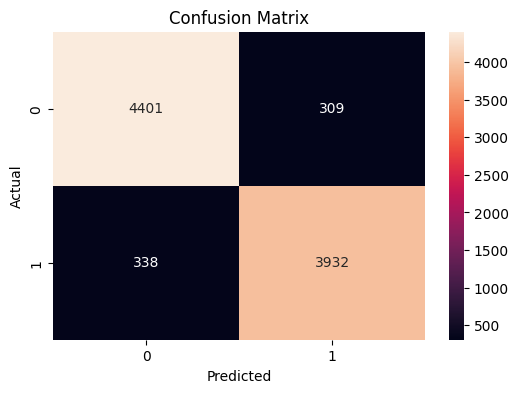

In [22]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

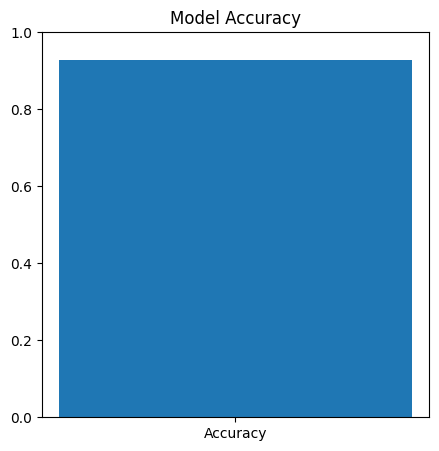

In [23]:
#Accuracy Graph
plt.figure(figsize=(5,5))

plt.bar(
    ["Accuracy"],
    [accuracy]
)

plt.ylim(0,1)

plt.title("Model Accuracy")

plt.show()

In [24]:
#Save Model
import pickle

pickle.dump(model, open("fake_news_model.pkl","wb"))

pickle.dump(tfidf, open("tfidf.pkl","wb"))

In [25]:
#User Input Prediction
import pickle

model = pickle.load(open("fake_news_model.pkl","rb"))

tfidf = pickle.load(open("tfidf.pkl","rb"))

In [26]:
def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [stemmer.stem(word) for word in tokens]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [33]:
while True:

    news = input("\nEnter News Article (or type 'exit' to quit): ")

    if news.lower() == "exit":
        break

    clean_news = preprocess(news)

    vector = tfidf.transform([clean_news])

    prediction = model.predict(vector)

    probability = model.predict_proba(vector)

    if prediction[0] == 1:
        print("✅ REAL NEWS")
        print("Confidence:", round(max(probability[0])*100,2), "%")
    else:
        print("❌ FAKE NEWS")
        print("Confidence:", round(max(probability[0])*100,2), "%")

❌ FAKE NEWS
Confidence: 54.48 %
✅ REAL NEWS
Confidence: 88.24 %
❌ FAKE NEWS
Confidence: 75.97 %
❌ FAKE NEWS
Confidence: 52.26 %
✅ REAL NEWS
Confidence: 85.29 %
✅ REAL NEWS
Confidence: 65.61 %
